In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
                            mean_squared_error, mean_absolute_error, r2_score,
                            accuracy_score, precision_score, recall_score, f1_score,
                            roc_curve, auc, confusion_matrix, log_loss
                            )

In [2]:
data = pd.read_csv('zuu crew scores.csv')
data['passed'] = (data['CapstoneScore'] >= 50).astype(int)
data = data[data['CourseName'] == 'Foundations of ML']
del data['MemberName'], data['CourseName']
data.head()

,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CapstoneScore,passed
0,3,79.9,43.7,2,0,62.8,5.0,45.3,0
1,2,76.8,95.6,6,0,87.4,2.7,78.8,1
2,3,96.6,75.9,8,0,98.4,2.8,65.4,1
4,2,83.2,24.0,6,0,41.8,4.2,40.1,0
7,3,86.5,88.0,5,0,23.9,1.3,68.2,1


### Regression

In [3]:
X = data.drop(columns=['CapstoneScore', 'passed'])
Y = data['CapstoneScore']

In [4]:
def l1_linear_regression(
                        X, Y, 
                        lr = 1e-4, 
                        lambda_reg = 1e-4,
                        iterations = 1000
                        ):
    n, m = X.shape 
    w = np.random.randn(m)
    b0 = 0

    loss_arr = []

    ''' 
    w = betas means weights
    '''

    for epoch in range(iterations):
        # Forward pass
        yhat = b0 + np.dot(X, w)
        resid = Y - yhat # residual means error terms
        
        # Compute gradients with L1 regularization
        s = np.where(w>=0, 1, -1)
        grad_w = -np.dot(X.T, resid) / n + lambda_reg * s # dw = grad_w
        grad_b = -np.mean(resid) # db = grad_b
        
        # Standard gradient descent update
        w = w - lr * grad_w
        b0 = b0 - lr * grad_b
        
        # Compute total loss (MSE + L1 penalty)
        mse_loss = 0.5 * np.mean(resid**2)
        l1_panelty = lambda_reg * np.sum(np.abs(w))
        loss = mse_loss + l1_panelty
        loss_arr.append(loss)

    return w, b0, loss_arr

In [5]:
w1, b0_1, loss_arr_1 = l1_linear_regression(X, Y)

print(f"best w : {w1}")
print(f"best b0 : {b0_1}")

best w : [ 0.20290875  0.1953978   0.62422526 -0.03730302 -0.33283561  0.03460568
  0.78953288]
best b0 : 0.027599221648701443


In [6]:
w2, b0_2, loss_arr_2 = l1_linear_regression(X, Y, lambda_reg=1)

print(f"best w : {w1}")
print(f"best b0 : {b0_2}")

best w : [ 0.20290875  0.1953978   0.62422526 -0.03730302 -0.33283561  0.03460568
  0.78953288]
best b0 : 0.019885693882456878


Text(0, 0.5, 'loss')

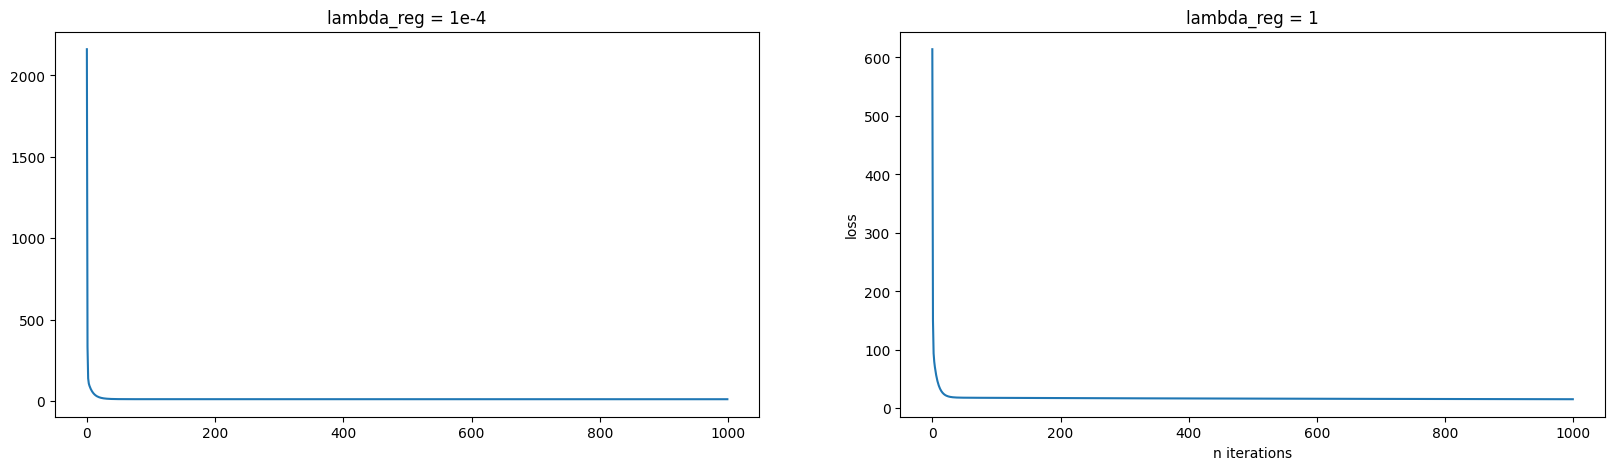

In [7]:
fig, ax = plt.subplots(1, 2, figsize = (20,5))
ax[0].plot(loss_arr_1)
ax[0].set_title('lambda_reg = 1e-4')

ax[1].plot(loss_arr_2)
ax[1].set_title('lambda_reg = 1')
plt.xlabel("n iterations")
plt.ylabel("loss")

In [8]:
Yhat_1 = b0_1 + np.dot(X, w1)
Yhat_2 = b0_2 + np.dot(X, w2)

In [9]:
mse_l2_1 = mean_squared_error(Y, Yhat_1)
mae_l2_1 = mean_absolute_error(Y, Yhat_1)
r2_l2_1 = r2_score(Y, Yhat_1)

mse_l2_2 = mean_squared_error(Y, Yhat_2)
mae_l2_2 = mean_absolute_error(Y, Yhat_2)
r2_l2_2 = r2_score(Y, Yhat_2)

In [10]:
print(f"MSE L1 | lambda_reg = 1e-4 : {mse_l2_1}")
print(f"MAE L1 | lambda_reg = 1e-4 : {mae_l2_1}")
print(f"R2 L1 | lambda_reg = 1e-4 : {r2_l2_1}")

print('\n')
print(f"MSE L1 | lambda_reg = 1 : {mse_l2_2}")
print(f"MAE L1 | lambda_reg = 1 : {mae_l2_2}")
print(f"R2 L1 | lambda_reg = 1 : {r2_l2_2}")

MSE L1 | lambda_reg = 1e-4 : 23.66546201129895
MAE L1 | lambda_reg = 1e-4 : 3.69379322130072
R2 L1 | lambda_reg = 1e-4 : 0.9171750961022666


MSE L1 | lambda_reg = 1 : 26.025996694641595
MAE L1 | lambda_reg = 1 : 3.8897066723669917
R2 L1 | lambda_reg = 1 : 0.9089136449545232


### Classification

In [11]:
X = data.drop(columns=['CapstoneScore', 'passed'])
Y = data['passed']

In [12]:
def sigmoid(z):
    """
    Numerically stable sigmoid function.
    
    Args:
        z: Input array or scalar
        
    Returns:
        Sigmoid of z
    """
    return 1.0 / (1.0 + np.exp(-z))

In [13]:
def l1_log_regression(
                        X, Y, 
                        lr = 1e-4, 
                        lambda_reg = 1e-4,
                        iterations = 1000
                        ):
    n, m = X.shape 
    w = np.random.randn(m)
    b0 = 0

    loss_arr = []

    ''' 
    w = betas means weights
    '''

    for epoch in range(iterations):
        # Forward pass
        z = b0 + np.dot(X, w)
        Yhat = sigmoid(z)
        resid = Y - Yhat # residual means error terms
        
        # Compute gradients with L1 regularization
        s = np.where(w>=0, 1, -1)
        grad_w = -np.dot(X.T, resid) / n + lambda_reg * s # dw = grad_w
        grad_b = -np.mean(resid) # db = grad_b
        
        # Standard gradient descent update
        w = w - lr * grad_w
        b0 = b0 - lr * grad_b
        
        # Compute total loss (BCE + L1 penalty)
        bce_loss = log_loss(Y, Yhat, labels=[0, 1])
        l1_panelty = lambda_reg * np.sum(np.abs(w))
        loss = bce_loss + l1_panelty
        loss_arr.append(loss)

    return w, b0, loss_arr

In [16]:
w1, b0_1, loss_arr_1 = l1_log_regression(X, Y)

print(f"best w : {w1}")
print(f"best b0 : {b0_1}")

print()
w2, b0_2, loss_arr_2 = l1_log_regression(X, Y, lambda_reg=1)

print(f"best w : {w1}")
print(f"best b0 : {b0_2}")

best w : [-0.06286649 -0.04903648  0.19571936 -1.2147424   1.03379316  0.02883987
 -0.14480024]
best b0 : -0.001963394806539265

best w : [-0.06286649 -0.04903648  0.19571936 -1.2147424   1.03379316  0.02883987
 -0.14480024]
best b0 : 0.00047118792030905474


Text(0, 0.5, 'loss')

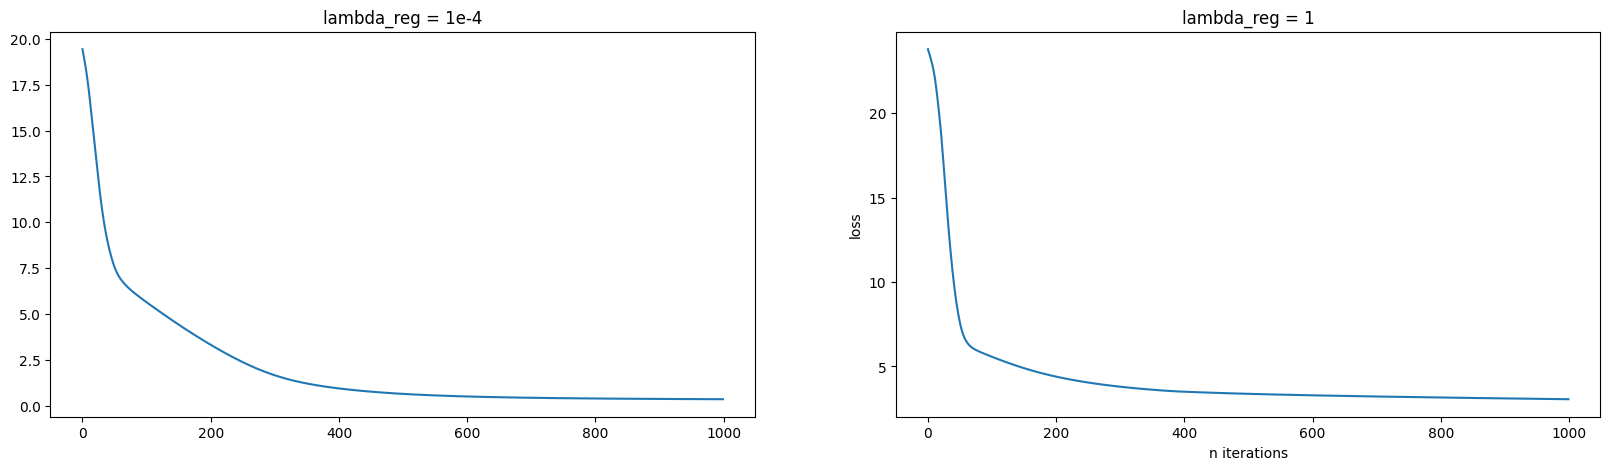

In [17]:
fig, ax = plt.subplots(1, 2, figsize = (20,5))
ax[0].plot(loss_arr_1)
ax[0].set_title('lambda_reg = 1e-4')

ax[1].plot(loss_arr_2)
ax[1].set_title('lambda_reg = 1')
plt.xlabel("n iterations")
plt.ylabel("loss")

In [18]:

Yhat_1 = sigmoid(b0_1 + np.dot(X, w1))
Yhat_2 = sigmoid(b0_2 + np.dot(X, w2))
Yhat_1 = Yhat_1 > 0.5
Yhat_2 = Yhat_2 > 0.5

accuracy_1 = accuracy_score(Y, Yhat_1)
precision_1 = precision_score(Y, Yhat_1)
recall_1 = recall_score(Y, Yhat_1)
f1_1 = f1_score(Y, Yhat_1)

accuracy_2 = accuracy_score(Y, Yhat_2)
precision_2 = precision_score(Y, Yhat_2)
recall_2 = recall_score(Y, Yhat_2)
f1_2 = f1_score(Y, Yhat_2)

print(f"Accuracy | lambda_reg = 1e-4 : {accuracy_1}")
print(f"Precisiom | lambda_reg = 1e-4 : {precision_1}")
print(f"Recall | lambda_reg = 1e-4 : {recall_1}")
print(f"F1 Score | lambda_reg = 1e-4 : {f1_1}")

print("\n")
print(f"Accuracy | lambda_reg = 1 : {accuracy_2}")
print(f"Precisiom | lambda_reg = 1 : {precision_2}")
print(f"Recall | lambda_reg = 1 : {recall_2}")
print(f"F1 Score | lambda_reg = 1 : {f1_2}")

Accuracy | lambda_reg = 1e-4 : 0.8888888888888888
Precisiom | lambda_reg = 1e-4 : 0.9047619047619048
Recall | lambda_reg = 1e-4 : 0.9047619047619048
F1 Score | lambda_reg = 1e-4 : 0.9047619047619048


Accuracy | lambda_reg = 1 : 0.9027777777777778
Precisiom | lambda_reg = 1 : 0.926829268292683
Recall | lambda_reg = 1 : 0.9047619047619048
F1 Score | lambda_reg = 1 : 0.9156626506024096
